In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2026-07-04 08:55:47.575870: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-04 08:55:47.614173: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-04 08:55:53.612327: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [3]:
datasetPath = 'dataset/firstorder/kernel5-radius5/dataset.csv'

In [4]:
# Parameters
datasetPath = "dataset/glrlm/kernel5-radius5/300.dataset.csv"


In [5]:
# train/validation/test = 70/10/20
dataset = pd.read_csv(datasetPath)

train_data, temp_data = train_test_split(dataset, test_size=0.3, random_state=42)
validation_data, test_data = train_test_split(temp_data, test_size=2/3, random_state=42)

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

2026-07-04 08:56:05.850191: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-04 08:56:05.852005: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
import keras

In [8]:
%%time

# Train a Random Forest model.
model = tfdf.keras.RandomForestModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmpo4apobpl as temporary training directory


Reading training dataset...


Training dataset read in 0:00:03.411860. Found 235709 examples.


Training model...


[INFO 26-07-04 08:56:34.2096 UTC kernel.cc:1233] Loading model from path /tmp/tmpo4apobpl/model/ with prefix 40fa00ebd57f4811


[INFO 26-07-04 08:56:35.6190 UTC decision_forest.cc:734] Model loaded with 300 root(s), 1209702 node(s), and 16 input feature(s).
[INFO 26-07-04 08:56:35.6191 UTC abstract_model.cc:1362] Engine "RandomForestOptPred" built
[INFO 26-07-04 08:56:35.6191 UTC kernel.cc:1061] Use fast generic engine


Model trained in 0:00:26.386816


Compiling model...


Model compiled.


CPU times: user 4min 42s, sys: 1.71 s, total: 4min 44s
Wall time: 32.9 s


In [9]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

 1/34 [..............................] - ETA: 1:38 - loss: 0.0000e+00 - accuracy: 0.9320

 3/34 [=>............................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9263  

 5/34 [===>..........................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9262

 7/34 [=====>........................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9261

 9/34 [======>.......................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9256

...

29/34 [========================>.....] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9230

31/34 [==========================>...] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9229

33/34 [============================>.] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9225

34/34 [==============================] - 4s 31ms/step - loss: 0.0000e+00 - accuracy: 0.9227



loss: 0.0000
accuracy: 0.9227


In [10]:
# Model Summary
model.summary()

Model: "random_forest_model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


Total params: 1 (1.00 Byte)


Trainable params: 0 (0.00 Byte)


Non-trainable params: 1 (1.00 Byte)


_________________________________________________________________


Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (16):
	GrayLevelNonUniformity
	GrayLevelNonUniformityNormalized
	GrayLevelVariance
	HighGrayLevelRunEmphasis
	LongRunEmphasis
	LongRunHighGrayLevelEmphasis
	LongRunLowGrayLevelEmphasis
	LowGrayLevelRunEmphasis
	RunEntropy
	RunLengthNonUniformity
	RunLengthNonUniformityNormalized
	RunPercentage
	RunVariance
	ShortRunEmphasis
	ShortRunHighGrayLevelEmphasis
	ShortRunLowGrayLevelEmphasis

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.         "HighGrayLevelRunEmphasis"  0.196790 ################
    2.     "LongRunHighGrayLevelEmphasis"  0.183808 ##############
    3.    "ShortRunHighGrayLevelEmphasis"  0.147451 #########
    4.          "LowGrayLevelRunEmphasis"  0.122054 #####
    5.                       "RunEntropy"  0.118705 #####
    6.     "ShortRunLowGrayLevelEmphasis"  0.118294 #####
    7.           "GrayLevelNonUniformity"  0.112615 ####
    8.      "LongRunLowGrayLevelEmphasis"  0

In [11]:
# Model features
model.make_inspector().features()

["GrayLevelNonUniformity" (1; #0),
 "GrayLevelNonUniformityNormalized" (1; #1),
 "GrayLevelVariance" (1; #2),
 "HighGrayLevelRunEmphasis" (1; #3),
 "LongRunEmphasis" (1; #4),
 "LongRunHighGrayLevelEmphasis" (1; #5),
 "LongRunLowGrayLevelEmphasis" (1; #6),
 "LowGrayLevelRunEmphasis" (1; #7),
 "RunEntropy" (1; #8),
 "RunLengthNonUniformity" (1; #9),
 "RunLengthNonUniformityNormalized" (1; #10),
 "RunPercentage" (1; #11),
 "RunVariance" (1; #12),
 "ShortRunEmphasis" (1; #13),
 "ShortRunHighGrayLevelEmphasis" (1; #14),
 "ShortRunLowGrayLevelEmphasis" (1; #15)]

In [12]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("HighGrayLevelRunEmphasis" (1; #3),
   0.19678966384458838),
  ("LongRunHighGrayLevelEmphasis" (1; #5), 0.18380788726255462),
  ("ShortRunHighGrayLevelEmphasis" (1; #14), 0.14745099841439638),
  ("LowGrayLevelRunEmphasis" (1; #7), 0.12205411981769078),
  ("RunEntropy" (1; #8), 0.11870523291278796),
  ("ShortRunLowGrayLevelEmphasis" (1; #15), 0.11829377589080801),
  ("GrayLevelNonUniformity" (1; #0), 0.11261471017521475),
  ("LongRunLowGrayLevelEmphasis" (1; #6), 0.10410931919008112),
  ("GrayLevelNonUniformityNormalized" (1; #1), 0.0934542213949373),
  ("GrayLevelVariance" (1; #2), 0.08877501027864433),
  ("ShortRunEmphasis" (1; #13), 0.08742054532557468),
  ("RunVariance" (1; #12), 0.08594569667349697),
  ("RunLengthNonUniformityNormalized" (1; #10), 0.08586469473970246),
  ("RunLengthNonUniformity" (1; #9), 0.08307200012922034),
  ("RunPercentage" (1; #11), 0.08202109310908241),
  ("LongRunEmphasis" (1; #4), 0.08161948106082345)],
 'SUM_SCORE': [("HighGrayLev

In [13]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=235709, accuracy=0.8713279115085524, loss=0.46274833857825437, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

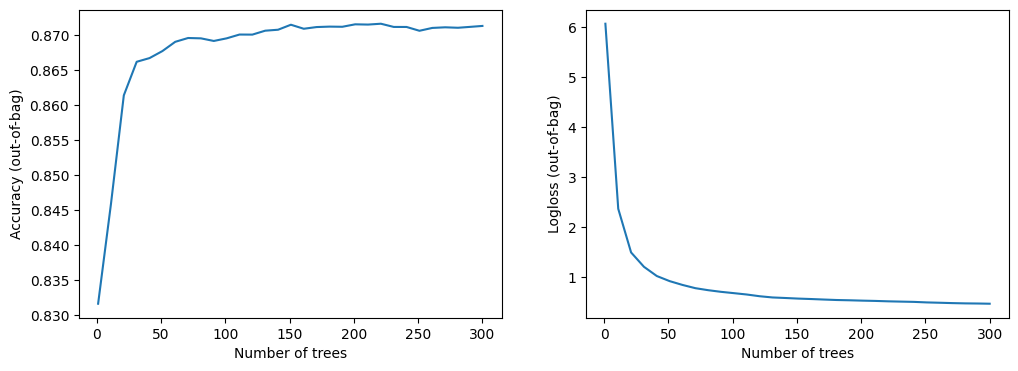

In [14]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

 1/34 [..............................] - ETA: 3s

 3/34 [=>............................] - ETA: 0s

 5/34 [===>..........................] - ETA: 0s

 7/34 [=====>........................] - ETA: 0s

 9/34 [======>.......................] - ETA: 0s

...

29/34 [========================>.....] - ETA: 0s

31/34 [==========================>...] - ETA: 0s

33/34 [============================>.] - ETA: 0s

34/34 [==============================] - 1s 31ms/step


The ROC AUC score is 0.95435


In [16]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

 1/68 [..............................] - ETA: 6s

 3/68 [>.............................] - ETA: 1s

 5/68 [=>............................] - ETA: 1s

 7/68 [==>...........................] - ETA: 1s

 9/68 [==>...........................] - ETA: 1s

...

65/68 [===========================>..] - ETA: 0s

67/68 [============================>.] - ETA: 0s

68/68 [==============================] - 2s 31ms/step


Sklearn binary metrics:


accuracy: 0.9208
precision: 0.4194
recall: 0.8048
f1: 0.5514
mcc: 0.5456
roc_auc: 0.9518
pr_auc: 0.6723
log_loss: 0.1926
brier_score: 0.0576

Confusion matrix:
 [[58735  4538]
 [  795  3278]]

Classification report:
               precision    recall  f1-score   support

           0     0.9866    0.9283    0.9566     63273
           1     0.4194    0.8048    0.5514      4073

    accuracy                         0.9208     67346
   macro avg     0.7030    0.8665    0.7540     67346
weighted avg     0.9523    0.9208    0.9321     67346

